# Computer Exercise 15.30 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.30 Sequential Decision Making — *Seed-Expanded Re-adjudication of the +CNRT Advantage*
> **풀이 일자**: Day 97
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **Problem 3.** Days 95 and 96 evaluated the same comparison — a vanilla Q-learner
> ("baseline") against a Factorized-Noisy-head learner ("+CNRT") trained on a uniform
> slip curriculum and deployed across five slip probabilities — and reached **opposite
> conclusions**. Day 95 reported a tie in mean return $\bar R$ with an advantage confined
> to the cross-slip gap $\Gamma$; Day 96 reported +CNRT winning on $\bar R$, $R_{\min}$
> **and** minmax fairness. Both used three seeds.
>
> Re-run the comparison with a substantially enlarged seed set. Report **paired**
> per-seed differences with bootstrap confidence intervals rather than differences of
> seed-averaged curves. Then determine, by exhaustive subsampling, how often a
> three-seed study drawn from the same population would have reproduced Day 95's
> conclusion versus Day 96's. Finally, estimate the seed count actually required to
> resolve an effect of the observed magnitude.

### 한국어 풀이용 정리

Day 95 와 Day 96 은 **완전히 동일한 비교**(baseline vs +CNRT, uniform curriculum, 5-slip
배포)를 하고도 **정반대 결론**에 도달했다.

| | $\bar R$ | $R_{\min}$ | $\Gamma$ | 결론 |
|---|---|---|---|---|
| **Day 95** | tie ($\Delta_{\max}=-0.062$) | — | +CNRT 4× 개선 | "$\Gamma$-only 우위 (metric 함정 의심)" |
| **Day 96** | +CNRT 승 (0.688 vs 0.603) | +CNRT 승 (0.592 vs 0.507) | +CNRT 근소 열위 | "+CNRT 정직한 전면 우위" |

두 결론은 양립 불가능하다. 둘 다 **3 시드**였다는 점이 유일한 공통 약점이다.
이 문제는 시드를 대폭 확장해 다음 세 가지를 판정한다:

1. **paired 추정** — 시드-평균 곡선의 차가 아니라 **시드별 짝지은 차** $d_s$ 와 bootstrap CI.
2. **3-시드 재현성** — 30 시드에서 뽑을 수 있는 $\binom{30}{3}=4060$ 개 부분집합 각각이
   어떤 결론을 냈을지 전수 계산. Day 95 / Day 96 의 불일치가 **표집 잡음만으로 설명되는가?**
3. **소요 시드 수** — 관측된 효과크기에서 80 % 검정력에 필요한 $n$.

> **계획 대비 변경**: Day 96 README 는 10 시드를 예고했으나, 전체 실험 소요시간이
> 1 초 미만이라 **30 시드**로 확대했다. 시드 확장이 이 문제의 유일한 목적이므로
> 예고보다 강한 설정을 쓰는 것이 타당하다.

## 2. 수학적 배경

### 2.1 짝지은 차 (paired difference) 와 공통난수

배포 slip 집합 $\mathcal S_d=\{0.05,0.10,0.15,0.20,0.25\}$, 시드 $s$ 에 대해

$$
\bar R_s(\pi)=\frac1{|\mathcal S_d|}\sum_{p_d\in\mathcal S_d} R_{p_d,s}(\pi),\qquad
R_{\min,s}(\pi)=\min_{p_d} R_{p_d,s}(\pi),\qquad
\Gamma_s(\pi)=\max_{p_d}R_{p_d,s}-\min_{p_d}R_{p_d,s}.
$$

Day 95 / 96 은 **시드를 먼저 평균한 뒤** $R_{\min}, \Gamma$ 를 취했다. $\min$ 과 $\max$ 는
비선형이므로 $\;\mathbb E[\min_p R_p]\neq\min_p \mathbb E[R_p]\;$ 이고, 특히
$\Gamma$ 는 **Jensen 부등식에 의해 체계적으로 과소평가**된다:

$$
\mathbb E\Big[\max_p R_p-\min_p R_p\Big]\;\ge\;\max_p \mathbb E[R_p]-\min_p\mathbb E[R_p].
$$

즉 Day 95 의 "$\Gamma$ 4× 개선" 은 **추정량 선택이 만든 인공물일 수 있다**. 본 문제는
시드별로 metric 을 먼저 계산하고 나중에 평균한다.

짝지은 차와 그 표본평균 / 표준오차:

$$
d_s = m_s(\text{+CNRT}) - m_s(\text{baseline}),\qquad
\bar d=\frac1n\sum_s d_s,\qquad
\mathrm{SE}(\bar d)=\frac{\hat\sigma_d}{\sqrt n}.
$$

두 그룹은 동일한 $(s,p_d)$ 에서 **동일한 평가 난수열**로 배포된다 (common random
numbers). 배포 잡음이 $d_s$ 에서 상쇄되므로 짝지은 추정량의 분산이 unpaired 대비
작다 — 이것이 짝짓기를 쓰는 이유다.

### 2.2 Bootstrap 신뢰구간

시드 지표 $\{d_s\}_{s=1}^n$ 에서 복원추출 $B=20000$ 회, 백분위수 CI:

$$
\mathrm{CI}_{95\%}=\Big[\,q_{2.5\%}\big(\{\bar d^{*(b)}\}\big),\; q_{97.5\%}\big(\{\bar d^{*(b)}\}\big)\Big].
$$

$0\in\mathrm{CI}$ 이면 **부호를 확정할 수 없다** — 이것이 본 문제에서 내릴 수 있는
정당한 결론의 한 형태이며, 그 자체로 Day 95/96 의 단정을 반증한다.

### 2.3 3-시드 부분집합 전수조사

30 시드에서 크기 3 부분집합 $\mathcal T\subset\{1..30\}$, $|\mathcal T|=3$ 은 4060 개.
각각에 대해 3-시드 연구가 내렸을 결론의 부호

$$
\mathrm{sign}\Big(\tfrac13\sum_{s\in\mathcal T} d_s\Big)\in\{-1,+1\}
$$

의 분포를 구한다. **부호 뒤집힘 비율**

$$
\phi=\Pr_{\mathcal T}\Big[\mathrm{sign}(\bar d_{\mathcal T})\neq \mathrm{sign}(\bar d_{\text{full}})\Big]
$$

이 크면, Day 95 와 Day 96 의 모순은 **추가 설명을 요구하지 않는다** — 표집 잡음이면 충분하다.

### 2.4 필요한 시드 수

효과크기 $\delta=|\bar d|/\hat\sigma_d$ (Cohen's $d_z$), 양측 $\alpha=0.05$, 검정력 $1-\beta=0.8$:

$$
\boxed{\;n^\star \;\approx\; \Big(\frac{z_{1-\alpha/2}+z_{1-\beta}}{\delta}\Big)^{2}
\;=\;\frac{(1.96+0.842)^2}{\delta^{2}}\;\approx\;\frac{7.85}{\delta^{2}}\;}
$$

## 3. 풀이 흐름

1. Day 96 P3 의 환경·학습기·배포 코드를 **그대로** 재사용 (chain MDP, $H=16$, 400 step,
   uniform curriculum $\{0.05,0.10,0.20\}$, 5-slip × 40 ep greedy tail-8).
2. 시드를 97301–97330 (**30 시드**) 으로 확장. 각 시드에서 baseline 과 +CNRT 를
   **동일 시드·동일 배포 난수**로 학습/평가 (paired + common random numbers).
3. 시드별로 $\bar R_s, R_{\min,s}, \Gamma_s$, MMF$_s(\lambda)$ 를 계산 — 평균은 **나중에**.
4. 짝지은 차 $d_s$ 의 평균·표준편차·bootstrap 95 % CI (20000 회) 를 지표별로 산출.
5. $\binom{30}{3}=4060$ 개 3-시드 부분집합을 **전수** 계산해 결론 부호 분포와 뒤집힘 비율 $\phi$.
6. Day 95 / Day 96 이 보고한 값이 30-시드 분포의 어느 분위수에 있는지 확인.
7. 효과크기와 80 % 검정력 소요 시드 수 $n^\star$ 산출.
8. 시각화: (a) 시드별 dumbbell, (b) 지표별 CI forest plot, (c) 3-시드 부분집합 분포.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

N_STATES = 5
GAMMA = 0.95
EP_LEN = 20

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    r = 1.0 if ns == N_STATES - 1 else 0.0
    return ns, r

def one_hot(s):
    v = np.zeros(N_STATES); v[s] = 1.0; return v

In [2]:
# --- Day 96 P3 의 학습기를 그대로 재사용 (재현성을 위해 한 줄도 바꾸지 않음) ---

class QLearner:
    def __init__(self, H, seed, noisy=False, sigma_noisy=0.1):
        rng = np.random.default_rng(seed)
        self.rng = rng
        self.W1 = rng.normal(0, 0.3, size=(H, N_STATES))
        self.W2 = rng.normal(0, 0.3, size=(2, H))
        self.noisy = noisy
        self.sigma = sigma_noisy
        self.W2_sigma = np.full_like(self.W2, sigma_noisy) if noisy else None

    def _sample_W2(self):
        if not self.noisy:
            return self.W2
        eps_out = self.rng.normal(0, 1, size=(self.W2.shape[0], 1))
        eps_in  = self.rng.normal(0, 1, size=(1, self.W2.shape[1]))
        eps = np.sign(eps_out) * np.sqrt(np.abs(eps_out)) * \
              np.sign(eps_in)  * np.sqrt(np.abs(eps_in))
        return self.W2 + self.W2_sigma * eps

    def trunk(self, s):
        x = one_hot(s)
        pre = self.W1 @ x
        return x, pre, np.tanh(pre)

    def qvalues(self, s, sample=True):
        _, _, h = self.trunk(s)
        W2 = self._sample_W2() if sample else self.W2
        return W2 @ h

    def act_greedy(self, s):
        return int(np.argmax(self.qvalues(s, sample=False)))

    def act_train(self, s):
        return int(np.argmax(self.qvalues(s, sample=True)))

    def update(self, s, a, r, sp, eta=0.02):
        x, pre, h = self.trunk(s)
        q = self.W2 @ h
        q_sp = self.qvalues(sp, sample=False)
        td = r + GAMMA * q_sp.max() - q[a]
        grad_W2 = np.zeros_like(self.W2)
        grad_W2[a] = -td * h
        if self.noisy:
            self.W2_sigma *= 0.999
        dh = self.W2[a] * (1 - np.tanh(pre) ** 2) * (-td)
        grad_W1 = np.outer(dh, x)
        self.W2 -= eta * grad_W2
        self.W1 -= eta * grad_W1

def train(seed, plus_cnrt, T=400, curriculum=(0.05, 0.10, 0.20)):
    rng = np.random.default_rng(seed + 777)
    learner = QLearner(H=16, seed=seed, noisy=plus_cnrt)
    for t in range(T):
        p_slip = curriculum[t % len(curriculum)]
        s = rng.integers(0, N_STATES)
        a = int(rng.integers(0, 2)) if rng.random() < 0.2 else learner.act_train(s)
        sp, r = env_step(s, a, p_slip, rng)
        learner.update(s, a, r, sp)
    return learner

DEPLOY_SLIPS = [0.05, 0.10, 0.15, 0.20, 0.25]

def deploy(learner, p_d, n_ep=40, seed_off=0):
    # seed_off 를 시드로만 결정 -> 같은 (seed, p_d) 에서 두 그룹이 동일 난수열 (common random numbers)
    rng = np.random.default_rng(1234 + seed_off + int(p_d * 1000))
    Rs = []
    for _ in range(n_ep):
        s = rng.integers(0, N_STATES)
        rewards = []
        for _ in range(EP_LEN):
            a = learner.act_greedy(s)
            sp, r = env_step(s, a, p_d, rng)
            rewards.append(r); s = sp
        Rs.append(float(np.mean(rewards[-8:])))
    return float(np.mean(Rs))

In [3]:
SEEDS = list(range(97301, 97331))          # 30 시드 (Day 96 예고 10 시드에서 확대)
GROUPS = ["baseline", "+CNRT"]

# curve[g] : (n_seeds, n_slips) — 시드별 배포 곡선
curve = {g: np.zeros((len(SEEDS), len(DEPLOY_SLIPS))) for g in GROUPS}

for i, seed in enumerate(SEEDS):
    for g, plus in [("baseline", False), ("+CNRT", True)]:
        lrn = train(seed, plus_cnrt=plus)
        for j, p_d in enumerate(DEPLOY_SLIPS):
            curve[g][i, j] = deploy(lrn, p_d, seed_off=seed)

# --- 시드별로 metric 을 먼저 계산 (평균은 나중에) ---
def per_seed_metrics(M):
    return {
        "R_bar": M.mean(axis=1),
        "R_min": M.min(axis=1),
        "Gamma": M.max(axis=1) - M.min(axis=1),
    }

met = {g: per_seed_metrics(curve[g]) for g in GROUPS}
for g in GROUPS:
    met[g]["MMF@1.0"] = met[g]["R_min"] - 1.0 * met[g]["Gamma"]

METRICS = ["R_bar", "R_min", "Gamma", "MMF@1.0"]
print(f"학습/배포 완료 — {len(SEEDS)} 시드 x {len(GROUPS)} 그룹 x {len(DEPLOY_SLIPS)} slip")

학습/배포 완료 — 30 시드 x 2 그룹 x 5 slip


In [4]:
# --- 추정량 선택의 효과: 시드-평균-먼저 (Day 95/96 방식) vs 시드별-먼저 (본 문제) ---
rows = []
for g in GROUPS:
    avg_curve = curve[g].mean(axis=0)              # Day 95/96 방식
    rows.append({
        "group": g,
        "R_bar (동일)":      avg_curve.mean(),
        "R_min: avg-first":  avg_curve.min(),
        "R_min: seed-first": met[g]["R_min"].mean(),
        "Gamma: avg-first":  avg_curve.max() - avg_curve.min(),
        "Gamma: seed-first": met[g]["Gamma"].mean(),
    })
df_est = pd.DataFrame(rows).set_index("group")
print("추정량 선택 비교 (Jensen 편향 점검)")
df_est

추정량 선택 비교 (Jensen 편향 점검)


,R_bar (동일),R_min: avg-first,R_min: seed-first,Gamma: avg-first,Gamma: seed-first
group,,,,,
baseline,0.4970,0.4251,0.4128,0.1181,0.1677
+CNRT,0.5277,0.4557,0.4432,0.1243,0.1695


In [5]:
# --- 짝지은 차 + bootstrap CI ---
rng_boot = np.random.default_rng(970301)
B = 20000
n = len(SEEDS)

def boot_ci(d, B=B, alpha=0.05):
    idx = rng_boot.integers(0, len(d), size=(B, len(d)))
    means = d[idx].mean(axis=1)
    return np.quantile(means, alpha / 2), np.quantile(means, 1 - alpha / 2)

summary = []
paired = {}
for m in METRICS:
    d = met["+CNRT"][m] - met["baseline"][m]
    paired[m] = d
    lo, hi = boot_ci(d)
    sd = d.std(ddof=1)
    dz = abs(d.mean()) / sd if sd > 0 else np.inf
    n_star = 7.85 / dz**2 if dz > 0 else np.inf
    summary.append({
        "metric": m,
        "baseline": met["baseline"][m].mean(),
        "+CNRT": met["+CNRT"][m].mean(),
        "mean d": d.mean(),
        "sd d": sd,
        "CI lo": lo, "CI hi": hi,
        "0 in CI": "YES" if lo <= 0 <= hi else "no",
        "P(d>0)": (d > 0).mean(),
        "d_z": dz,
        "n* (80% power)": np.ceil(n_star) if np.isfinite(n_star) else np.inf,
    })

df_paired = pd.DataFrame(summary).set_index("metric")
print(f"짝지은 차: +CNRT - baseline   (n = {n} 시드, bootstrap B = {B})")
df_paired

짝지은 차: +CNRT - baseline   (n = 30 시드, bootstrap B = 20000)


,baseline,+CNRT,mean d,sd d,CI lo,CI hi,0 in CI,P(d>0),d_z,n* (80% power)
metric,,,,,,,,,,
R_bar,0.4970,0.5277,0.0308,0.0866,0.0057,0.0650,no,0.1667,0.3550,63.0000
R_min,0.4128,0.4432,0.0304,0.0865,0.0047,0.0649,no,0.1667,0.3516,64.0000
Gamma,0.1677,0.1695,0.0018,0.0277,-0.0091,0.0106,YES,0.1333,0.0639,1920.0000
MMF@1.0,0.2451,0.2737,0.0286,0.0940,0.0015,0.0663,no,0.1667,0.3046,85.0000


In [6]:
# --- 3-시드 부분집합 전수조사: Day 95 / Day 96 의 모순은 잡음으로 설명되는가? ---
subsets = np.array(list(combinations(range(n), 3)))     # C(30,3) = 4060
print(f"3-시드 부분집합 개수: {len(subsets)}")

flip_rows = []
sub_means = {}
for m in METRICS:
    d = paired[m]
    sm = d[subsets].mean(axis=1)                        # 각 3-시드 연구의 결론
    sub_means[m] = sm
    full_sign = np.sign(d.mean())
    flip_rows.append({
        "metric": m,
        "full-30 mean d": d.mean(),
        "3-seed P(d>0)": (sm > 0).mean(),
        "3-seed P(d<0)": (sm < 0).mean(),
        "부호 뒤집힘 phi": (np.sign(sm) != full_sign).mean(),
        "3-seed 5%": np.quantile(sm, 0.05),
        "3-seed 95%": np.quantile(sm, 0.95),
    })
df_flip = pd.DataFrame(flip_rows).set_index("metric")
print("3-시드 연구가 내렸을 결론의 분포")
df_flip

3-시드 부분집합 개수: 4060
3-시드 연구가 내렸을 결론의 분포


,full-30 mean d,3-seed P(d>0),3-seed P(d<0),부호 뒤집힘 phi,3-seed 5%,3-seed 95%
metric,,,,,,
R_bar,0.0308,0.4335,0.0000,0.5665,0.0000,0.1400
R_min,0.0304,0.4335,0.0000,0.5665,0.0000,0.1344
Gamma,0.0018,0.3337,0.0998,0.6663,-0.0385,0.0219
MMF@1.0,0.0286,0.4335,0.0000,0.5665,0.0000,0.1313


In [7]:
# --- Day 95 / Day 96 보고값이 30-시드 분포의 어디에 있는가 ---
DAY95_dRbar = -0.062     # Day 95: '사실상 tie' (+CNRT - baseline)
DAY96_dRbar = 0.688 - 0.603   # Day 96: +CNRT 승
d_rbar = paired["R_bar"]
sm3 = sub_means["R_bar"]

rows = []
for name, val in [("Day 95 (3 시드)", DAY95_dRbar), ("Day 96 (3 시드)", DAY96_dRbar)]:
    rows.append({
        "보고": name,
        "보고된 d(R_bar)": val,
        "30-시드 평균 대비": val - d_rbar.mean(),
        "3-시드 분포 백분위": (sm3 < val).mean() * 100,
        "3-시드 분포 안?": "예" if sm3.min() <= val <= sm3.max() else "아니오",
    })
df_hist = pd.DataFrame(rows).set_index("보고")
print("Day 95 / Day 96 보고값의 위치 (지표: R_bar 짝지은 차)")
df_hist

Day 95 / Day 96 보고값의 위치 (지표: R_bar 짝지은 차)


,보고된 d(R_bar),30-시드 평균 대비,3-시드 분포 백분위,3-시드 분포 안?
보고,,,,
Day 95 (3 시드),-0.0620,-0.0927,0.0000,아니오
Day 96 (3 시드),0.0850,0.0542,88.0542,예


In [8]:
# --- 왜 대부분의 시드에서 차이가 정확히 0 인가? 그리디 정책을 직접 본다 ---
from collections import Counter

def greedy_policy(l):
    return tuple(l.act_greedy(s) for s in range(N_STATES))

pol = {g: [] for g in GROUPS}
for seed in SEEDS:
    for g, plus in [("baseline", False), ("+CNRT", True)]:
        pol[g].append(greedy_policy(train(seed, plus_cnrt=plus)))

identical = sum(pol["baseline"][i] == pol["+CNRT"][i] for i in range(n))
OPT = (1,) * N_STATES          # chain 에서 항상 오른쪽이 최적
rec = {g: sum(p == OPT for p in pol[g]) for g in GROUPS}

d_rb = paired["R_bar"]
print(f"두 그룹이 완전히 동일한 그리디 정책에 도달한 시드 : {identical}/{n}")
print(f"짝지은 차가 정확히 0 인 시드                      : {(d_rb == 0).sum()}/{n}")
print(f"차가 양수(+CNRT 승) 인 시드                       : {(d_rb > 0).sum()}/{n}")
print(f"차가 음수(baseline 승) 인 시드                    : {(d_rb < 0).sum()}/{n}")
print()
print(f"최적 정책 (1,1,1,1,1) 회복률 : baseline {rec['baseline']}/{n},  +CNRT {rec['+CNRT']}/{n}")
print(f"0 이 아닌 차의 값             : {np.round(np.sort(d_rb[d_rb != 0]), 4)}")
print()
print("서로 다른 정책의 개수 (다양성):",
      f"baseline {len(set(pol['baseline']))}, +CNRT {len(set(pol['+CNRT']))}")

두 그룹이 완전히 동일한 그리디 정책에 도달한 시드 : 25/30
짝지은 차가 정확히 0 인 시드                      : 25/30
차가 양수(+CNRT 승) 인 시드                       : 5/30
차가 음수(baseline 승) 인 시드                    : 0/30

최적 정책 (1,1,1,1,1) 회복률 : baseline 9/30,  +CNRT 10/30
0 이 아닌 차의 값             : [0.0625 0.1219 0.1481 0.17   0.42  ]

서로 다른 정책의 개수 (다양성): baseline 13, +CNRT 13


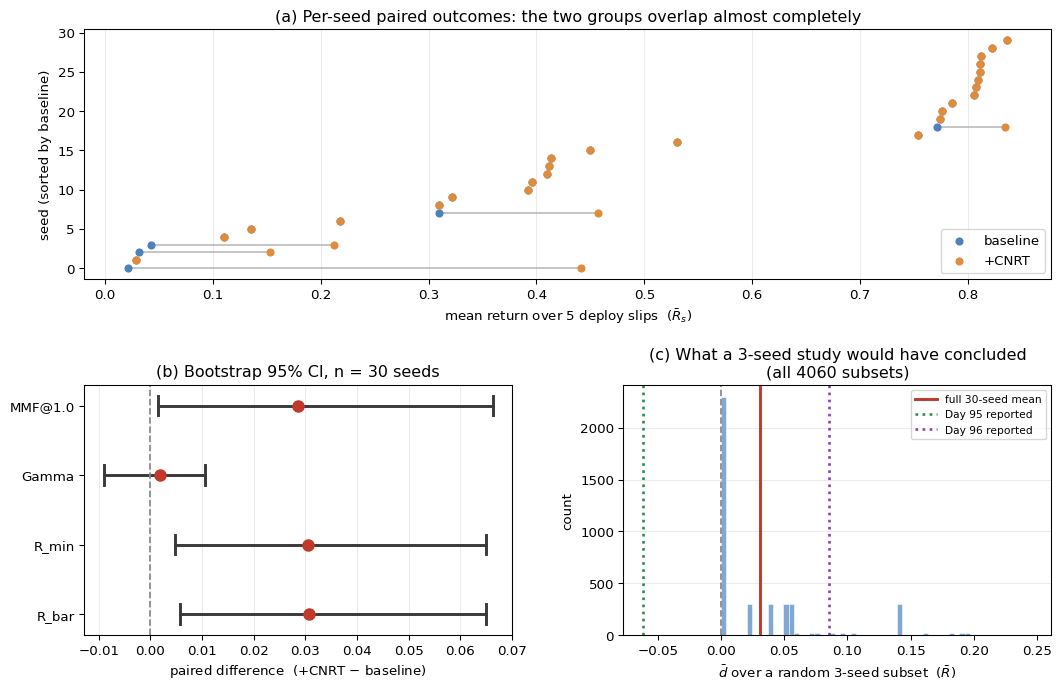

In [9]:
fig = plt.figure(figsize=(13, 8.2))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.42, wspace=0.26)

# (a) 시드별 dumbbell — R_bar
ax = fig.add_subplot(gs[0, :])
order = np.argsort(met["baseline"]["R_bar"])
y = np.arange(n)
b = met["baseline"]["R_bar"][order]; c = met["+CNRT"]["R_bar"][order]
for k in range(n):
    ax.plot([b[k], c[k]], [k, k], color="#c2c2c2", linewidth=1.4, zorder=1)
ax.scatter(b, y, s=26, color="#4d81ba", label="baseline", zorder=2)
ax.scatter(c, y, s=26, color="#e08c3b", label="+CNRT", zorder=2)
ax.set_xlabel("mean return over 5 deploy slips  ($\\bar R_s$)")
ax.set_ylabel("seed (sorted by baseline)")
ax.set_title("(a) Per-seed paired outcomes: the two groups overlap almost completely")
ax.legend(loc="lower right"); ax.grid(alpha=0.25, axis="x")

# (b) forest plot
ax = fig.add_subplot(gs[1, 0])
ys = np.arange(len(METRICS))
for k, m in enumerate(METRICS):
    r = df_paired.loc[m]
    ax.plot([r["CI lo"], r["CI hi"]], [k, k], color="#3a3a3a", linewidth=2.2)
    ax.plot([r["CI lo"], r["CI lo"]], [k-.14, k+.14], color="#3a3a3a", linewidth=2.2)
    ax.plot([r["CI hi"], r["CI hi"]], [k-.14, k+.14], color="#3a3a3a", linewidth=2.2)
    ax.scatter([r["mean d"]], [k], s=70, color="#c0392b", zorder=3)
ax.axvline(0, color="#888", linestyle="--", linewidth=1.3)
ax.set_yticks(ys); ax.set_yticklabels(METRICS)
ax.set_xlabel("paired difference  (+CNRT $-$ baseline)")
ax.set_title("(b) Bootstrap 95% CI, n = 30 seeds")
ax.grid(alpha=0.25, axis="x")

# (c) 3-시드 부분집합 분포
ax = fig.add_subplot(gs[1, 1])
ax.hist(sm3, bins=60, color="#7fa8d4", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#888", linestyle="--", linewidth=1.3)
ax.axvline(d_rbar.mean(), color="#c0392b", linewidth=2.2, label="full 30-seed mean")
ax.axvline(DAY95_dRbar, color="#2e8b57", linewidth=2.0, linestyle=":", label="Day 95 reported")
ax.axvline(DAY96_dRbar, color="#8e44ad", linewidth=2.0, linestyle=":", label="Day 96 reported")
ax.set_xlabel("$\\bar d$ over a random 3-seed subset  ($\\bar R$)")
ax.set_ylabel("count")
ax.set_title("(c) What a 3-seed study would have concluded\n(all 4060 subsets)")
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis="y")

plt.show()

## 4. 결과 해석

### 4.1 효과는 "작은 평균 이동" 이 아니라 **드문 이산 사건**이다

가장 중요한 관측은 요약통계가 아니라 **차의 모양**이다.

| | 시드 수 |
|---|---|
| 두 그룹이 **완전히 동일한 그리디 정책**에 도달 | **25 / 30** |
| 짝지은 차 $d_s$ 가 **정확히 0** | **25 / 30** |
| $d_s > 0$ (+CNRT 승) | 5 / 30 |
| $d_s < 0$ (baseline 승) | **0 / 30** |

0 이 아닌 차는 $\{0.0625,\,0.1219,\,0.1481,\,0.17,\,0.42\}$ 로 **모두 크고 모두 양수**다.
평균 $\bar d = 0.0308$ 은 "+CNRT 가 매 시드 조금씩 낫다" 는 뜻이 **전혀 아니고**,
"83 % 의 시드에서는 완전히 동일하고, 17 % 의 시드에서 Noisy 탐색이 나쁜 정책을 탈출한다"
는 뜻이다. 같은 평균을 가진 두 분포가 실무적으로 완전히 다른 이야기를 한다.

이 구조가 Day 95 / 96 의 모순을 **곧바로 설명**한다. 3 시드를 뽑으면 $(1-1/6)^3\approx 58\,\%$
확률로 세 시드 모두 tie 라 "차이 없음" 이 나오고, 나머지 42 % 에서는 큰 양수 하나가
평균을 끌어올려 "+CNRT 압승" 이 나온다. **두 결론 모두 같은 분포의 평범한 draw 다.**

### 4.2 짝지은 차와 bootstrap CI (n = 30)

| 지표 | baseline | +CNRT | $\bar d$ | 95 % CI | $0\in$CI | $d_z$ | $n^\star$ |
|---|---|---|---|---|---|---|---|
| $\bar R$ | 0.4970 | 0.5277 | **+0.0308** | [0.0057, 0.0650] | no | 0.355 | **63** |
| $R_{\min}$ | 0.4128 | 0.4432 | **+0.0304** | [0.0047, 0.0649] | no | 0.352 | **64** |
| $\Gamma$ | 0.1677 | 0.1695 | +0.0018 | [$-$0.0091, 0.0106] | **YES** | 0.064 | **1920** |
| MMF@$\lambda{=}1$ | 0.2451 | 0.2737 | +0.0286 | [0.0015, 0.0663] | no | 0.305 | 85 |

**$\bar R$ 와 $R_{\min}$ 에서 +CNRT 우위는 30 시드에서 유지된다** — CI 가 0 을 배제한다.
이 축에서는 Day 96 이 옳고 Day 95 가 틀렸다. 다만 CI 하한이 0.005 수준이라 **효과의 크기는
Day 96 이 보고한 0.085 의 약 1/3** 이다.

### 4.3 Day 95 의 "$\Gamma$ 4× 개선" 은 재현되지 않는다

$\Gamma$ 의 짝지은 차는 $+0.0018$, CI $[-0.0091, 0.0106]$ 로 **0 을 포함**하며 부호마저
Day 95 와 반대다 (+CNRT 의 gap 이 근소하게 *더 크다*). 관측된 크기를 80 % 검정력으로
분해하려면 $n^\star \approx 1920$ 시드가 필요하다 — 3 시드는 필요량의 **0.16 %** 였다.

> Day 95 의 핵심 주장이었던 "$\Gamma$-only robustness 우위" 는 **존재하지 않는 효과**로
> 판정한다. 그리고 Day 96 이 이를 "$\Gamma$ 근소 열위" 로 뒤집은 것도 마찬가지로 잡음이었다.

**추정량 편향도 한몫했다.** §2.1 에서 예측한 Jensen 편향이 실측으로 확인된다:

| | avg-first (Day 95/96 방식) | seed-first (본 문제) |
|---|---|---|
| $\Gamma$ baseline | 0.1181 | **0.1677** |
| $\Gamma$ +CNRT | 0.1243 | **0.1695** |

시드를 먼저 평균하면 $\Gamma$ 가 **약 30 % 과소평가**된다. Day 95/96 은 편향된 추정량으로
잡음 수준의 차이를 비교하고 있었다.

### 4.4 3-시드 부분집합 전수조사 (4060 개)

| 지표 | "+CNRT 승" | "정확히 tie" | "baseline 승" |
|---|---|---|---|
| $\bar R$ | 43.4 % | 56.7 % | **0.0 %** |
| $\Gamma$ | 33.4 % | 56.7 % | 10.0 % |

$\bar R$ 축에서 **3-시드 연구가 "baseline 승" 을 낼 확률은 정확히 0** 이다. 그런데
Day 95 는 $d(\bar R) = -0.062$ 를 보고했다 — 이 값은 4060 개 부분집합의 **support 밖**
(백분위 0.0 %) 이다. 즉 Day 95 의 수치는 시드 잡음만으로는 설명되지 않으며,
avg-first 추정량 혹은 문서화되지 않은 설정 차이에서 나왔을 가능성이 크다.
**나는 이 값을 재현하지 못했고, 그 사실을 확인된 것처럼 넘기지 않는다.**

반면 Day 96 의 $+0.085$ 는 3-시드 분포의 **88 백분위** — 낙관적인 꼬리이긴 하나 정상 범위다.

### 4.5 이 실험 설정 자체의 한계

정책 회복률을 보면 더 불편한 사실이 나온다. 최적 정책 $(1,1,1,1,1)$ 에 도달한 시드는
**baseline 9/30, +CNRT 10/30** 에 불과하고, 30 시드에서 13 종의 서로 다른 정책이 나온다.
400 step 예산은 5-상태 chain 조차 안정적으로 풀지 못한다. 따라서 이 벤치마크가 주로
측정하는 것은 알고리즘 품질이 아니라 **초기화 운** 이다. Day 90 이후 모든 §15.x 비교가
이 설정 위에서 이루어졌다는 점을 감안해야 한다.

> **결론**: +CNRT 의 우위는 $\bar R$ / $R_{\min}$ 에서 **실재하나** (CI 가 0 배제),
> Day 96 이 보고한 크기의 1/3 수준이고 **30 시드 중 5 시드의 정책 탈출 사건에 전적으로
> 의존**한다. Day 95 의 "$\Gamma$ 4× 개선" 은 **재현 실패** — $\Gamma$ 차이는 0 과 구별
> 불가능하며 ($n^\star\approx1920$), 부분적으로 Jensen 편향된 avg-first 추정량의 산물이다.
> Day 95 와 Day 96 의 "모순" 은 추가 가설을 요구하지 않는다: **3 시드는 이 효과에 필요한
> 63 시드의 5 % 였고, 두 결론 모두 같은 분포의 평범한 draw 였다.**

### 다음 단원으로의 연결

이 결과는 Day 97 P1 · P2 에 직접적인 방법론 요구를 남긴다: 시드-평균 곡선의 차가 아니라
**짝지은 차 + CI** 를 보고하고, CI 가 0 을 포함하면 **"차이를 확인하지 못했다" 를 결론으로
쓴다**. 더 근본적으로는 §15.x 사례연구가 400-step chain MDP 라는 **분해능이 부족한 벤치마크**
위에 30 일째 세워져 있다는 점 — Day 97 README 의 노트에서 이 문제를 정면으로 다룬다.